In [110]:
import numpy as nm 
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr

In [111]:
df = pd.read_csv('/kaggle/input/datasets/jackdaoud/marketing-data/ifood_df.csv')

In [112]:
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [114]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [115]:
df.shape

(2205, 39)

In [116]:
df.corr()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
Income,1.000000,-0.531699,0.042483,0.006716,0.730495,0.537920,0.702500,0.551758,0.555601,0.417653,...,-0.001960,0.044336,-0.060621,-0.239604,0.017644,0.021633,0.091176,0.823066,0.816879,0.388247
Kidhome,-0.531699,1.000000,-0.040207,0.011829,-0.499288,-0.374388,-0.445665,-0.389895,-0.379101,-0.356550,...,0.007422,-0.072244,0.019050,0.055308,-0.001930,0.011482,-0.042031,-0.551152,-0.539828,-0.212080
Teenhome,0.042483,-0.040207,1.000000,0.013881,0.002783,-0.176925,-0.267177,-0.206371,-0.164246,-0.019619,...,0.027181,0.047962,-0.056259,-0.120519,-0.024698,0.023806,0.092901,-0.142995,-0.146866,-0.130255
Recency,0.006716,0.011829,0.013881,1.000000,0.016470,-0.004909,0.026138,0.001177,0.025535,0.018558,...,0.023908,-0.001348,-0.006789,-0.003093,0.031419,-0.025563,-0.009234,0.021132,0.020241,-0.013344
MntWines,0.730495,-0.499288,0.002783,0.016470,1.000000,0.384947,0.593119,0.395967,0.388613,0.390194,...,0.005915,0.034139,-0.096259,-0.140369,-0.060920,0.036403,0.160804,0.902310,0.901848,0.509913
MntFruits,0.537920,-0.374388,-0.176925,-0.004909,0.384947,1.000000,0.568100,0.592556,0.570986,0.392596,...,-0.014210,0.025961,0.025452,-0.060915,0.114919,-0.055581,-0.084301,0.606658,0.594180,0.155133
MntMeatProducts,0.702500,-0.445665,-0.267177,0.026138,0.593119,0.568100,1.000000,0.595673,0.556511,0.375581,...,-0.004064,0.017370,-0.041738,-0.111968,0.064917,-0.004020,-0.004194,0.861392,0.860663,0.319553
MntFishProducts,0.551758,-0.389895,-0.206371,0.001177,0.395967,0.592556,0.595673,1.000000,0.582974,0.425420,...,0.015502,0.041886,0.061304,-0.059840,0.106227,-0.050153,-0.103952,0.635038,0.620626,0.174675
MntSweetProducts,0.555601,-0.379101,-0.164246,0.025535,0.388613,0.570986,0.556511,0.582974,1.000000,0.355747,...,-0.011220,0.049347,0.060550,-0.057863,0.104075,-0.067723,-0.085702,0.604514,0.595394,0.200174
MntGoldProds,0.417653,-0.356550,-0.019619,0.018558,0.390194,0.392596,0.375581,0.425420,0.355747,1.000000,...,-0.010375,0.043096,0.019189,-0.065014,0.131759,-0.032492,-0.119708,0.463694,0.388776,0.194647


In [117]:
df.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married',
       'marital_Single', 'marital_Together', 'marital_Widow',
       'education_2n Cycle', 'education_Basic', 'education_Graduation',
       'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds',
       'AcceptedCmpOverall'],
      dtype='object')

In [118]:
df.isnull().sum()

Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [120]:
df.nunique()

Income                  1963
Kidhome                    3
Teenhome                   3
Recency                  100
MntWines                 775
MntFruits                158
MntMeatProducts          551
MntFishProducts          182
MntSweetProducts         176
MntGoldProds             212
NumDealsPurchases         15
NumWebPurchases           15
NumCatalogPurchases       13
NumStorePurchases         14
NumWebVisitsMonth         16
AcceptedCmp3               2
AcceptedCmp4               2
AcceptedCmp5               2
AcceptedCmp1               2
AcceptedCmp2               2
Complain                   2
Z_CostContact              1
Z_Revenue                  1
Response                   2
Age                       56
Customer_Days            662
marital_Divorced           2
marital_Married            2
marital_Single             2
marital_Together           2
marital_Widow              2
education_2n Cycle         2
education_Basic            2
education_Graduation       2
education_Mast

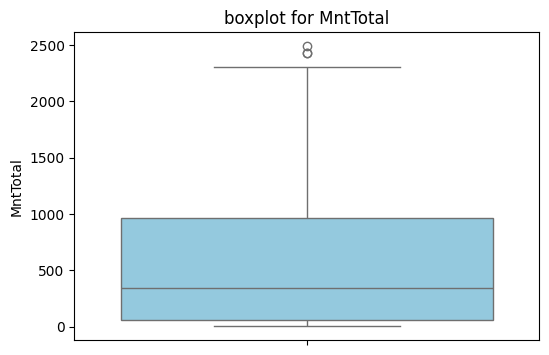

In [191]:
plt.figure(figsize=(6,4))
sns.boxplot(data = df, y= 'MntTotal', color= 'skyblue')
plt.title('boxplot for MntTotal')
plt.ylabel='MntTotal'
plt.show()

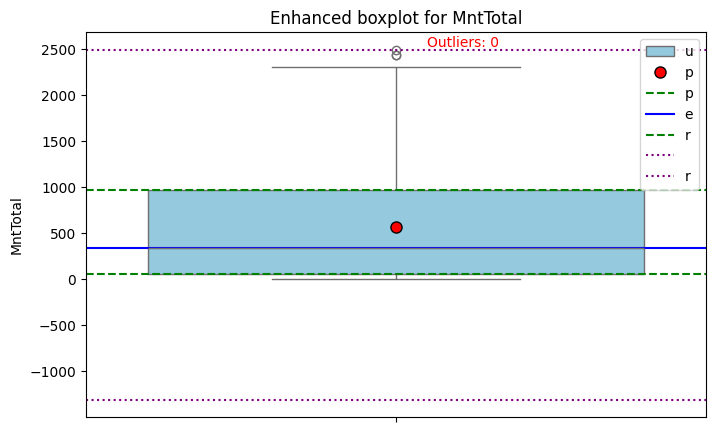

In [122]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

Q1 = df['MntTotal'].quantile(0.25)
Q2 = df['MntTotal'].median()
Q3 = df['MntTotal'].quantile(0.75)

IQR = Q3 - Q1

lower_whisker = min(df['MntTotal'].min(), Q1 - 1.5 * IQR)
upper_whisker = max(df['MntTotal'].max(), Q3 + 1.5 * IQR)

outliers = df[(df['MntTotal'] < lower_whisker) |
              (df['MntTotal'] > upper_whisker  )] ['MntTotal']

plt.figure(figsize=(8,5))

sns.boxplot(data=df, y ='MntTotal', color ='skyblue', showmeans =True, 
            meanprops={
                   'marker':'o',
                   'markerfacecolor':'red',
                   'markeredgecolor':'black',
                   'markersize':'8'
               }
               )

plt.axhline(Q1, color='green', linestyle='--', label=f'Q1: {Q1:.2f}')
plt.axhline(Q2, color='blue', linestyle='-', label=f'Median (Q2): {Q2:.2f}')
plt.axhline(Q3, color='green', linestyle='--', label=f'Q3: {Q3:.2f}')
plt.axhline(lower_whisker, color='purple', linestyle=':', label=f'lower_whisker: {lower_whisker:.2f}')
plt.axhline(upper_whisker, color='purple', linestyle=':', label=f'upper_whisker: {upper_whisker:.2f}')

plt.text(
    0.05,
    upper_whisker,
    f'Outliers: {len(outliers)}',
    fontsize='10',
    color='red',
    verticalalignment='bottom'
)

plt.title('Enhanced boxplot for MntTotal')
plt.ylabel='MntTotal'
plt.legend('upper right')
plt.show()

In [123]:
Q1 = df['MntTotal'].quantile(0.25)
Q3 = df['MntTotal'].quantile(0.75)

IQR = Q3 - Q1

lower_whisker =  Q1 - 1.5 * IQR
upper_whisker =  Q3 + 1.5 * IQR

outliers = df[(df['MntTotal'] < lower_whisker) |
              (df['MntTotal'] > upper_whisker  )]
outliers.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
1159,90638.0,0,0,29,1156,120,915,94,144,96,...,0,0,0,0,0,1,0,2429,2333,1
1467,87679.0,0,0,62,1259,172,815,97,148,33,...,1,0,0,0,1,0,0,2491,2458,3
1547,90638.0,0,0,29,1156,120,915,94,144,96,...,0,0,0,0,0,1,0,2429,2333,1


In [124]:
data = df[(df['MntTotal'] > lower_whisker) &
              (df['MntTotal'] < upper_whisker  )]
data.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2202.000000,2202.000000,2202.000000,2202.000000,2202.000000,2202.000000,2202.000000,2202.000000,2202.000000,2202.000000,...,2202.000000,2202.000000,2202.000000,2202.000000,2202.000000,2202.000000,2202.000000,2202.000000,2202.000000,2202.000000
mean,51570.283379,0.442779,0.507266,49.021344,304.960036,26.252044,164.336058,37.678474,26.967302,44.014986,...,0.257493,0.034514,0.089918,0.024523,0.504995,0.164396,0.216167,560.193915,516.178928,0.297457
std,20679.438848,0.537250,0.544429,28.944211,336.135586,39.589747,216.312982,54.821185,40.926101,51.747221,...,0.437353,0.182587,0.286130,0.154702,0.500089,0.370719,0.411723,572.096830,549.962471,0.678134
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.000000
25%,35182.500000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.000000
50%,51258.500000,0.000000,0.000000,49.000000,176.500000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,342.500000,288.000000,0.000000
75%,68146.500000,1.000000,1.000000,74.000000,505.000000,33.000000,230.750000,50.000000,33.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,962.000000,883.000000,0.000000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2304.000000,2259.000000,4.000000


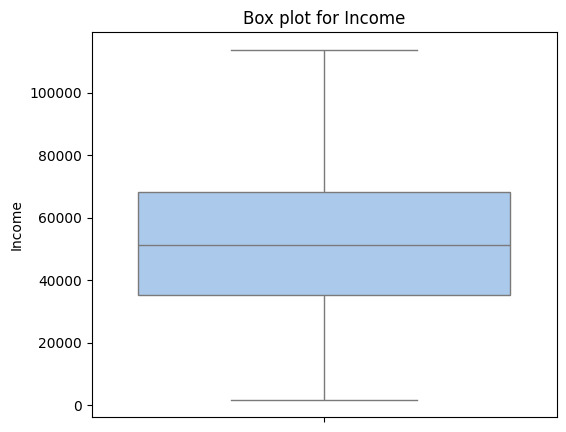

In [125]:
plt.figure(figsize=(6,5))
sns.boxplot(data=data, y='Income', palette= 'pastel')
plt.ylabel='Income'
plt.title('Box plot for Income')
plt.show()

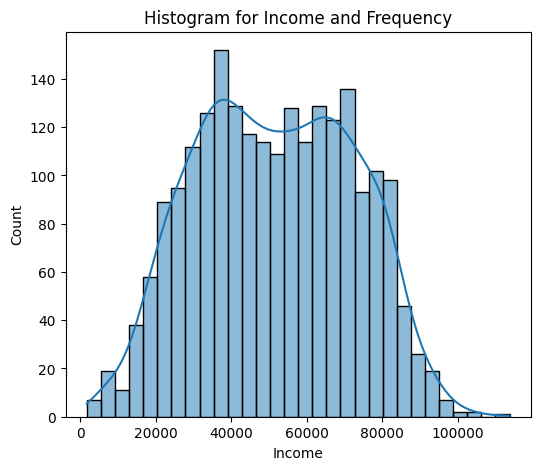

In [126]:
plt.figure(figsize=(6,5))
sns.histplot(data=data, x='Income', bins=30, kde=True, palette='virdis')
plt.title('Histogram for Income and Frequency')
plt.xlabel='Income'
plt.ylabel='Frequency'
plt.show()

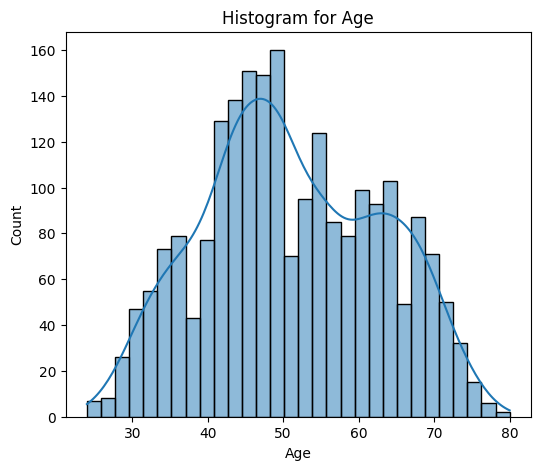

In [127]:
plt.figure(figsize=(6,5))
sns.histplot(data=data, x='Age', bins=30, kde=True)
plt.title('Histogram for Age')
plt.xlabel='Age'
plt.ylabel='Frequency'
plt.show()

In [128]:
print("skewness: %f" % data['Age'].skew())
print("kurtosis: %f" % data['Age'].kurt())

skewness: 0.091227
kurtosis: -0.796125


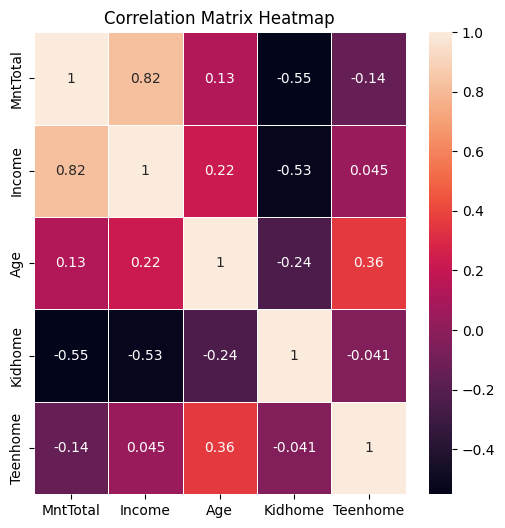

In [129]:
# Demographic columns
cols_demographics = ['Income', 'Age']

# Children related columns
cols_children = ['Kidhome', 'Teenhome']

# Marital status columns
cols_marital = [
    'marital_Divorced',
    'marital_Married',
    'marital_Single',
    'marital_Together',
    'marital_Widow'
]

# Product spending columns
cols_mnt = [
    'MntTotal',
    'MntRegularProds',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

# Communication related columns
cols_communication = [
    'Complain',
    'Response',
    'Customer_Days'
]

# Marketing campaign columns
cols_campaigns = [
    'AcceptedCmpOverall',
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5'
]

# Source of purchase columns
cols_source_of_purchase = [
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth'
]

# Education columns
cols_education = [
    'education_2n Cycle',
    'education_Basic',
    'education_Graduation',
    'education_Master',
    'education_PhD'
]

corr_matrix = data[['MntTotal'] + cols_demographics + cols_children].corr()
plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True, cmap='rocket', linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [130]:
for col in cols_marital:
    correlation, p_value = pointbiserialr(data[col], data['MntTotal'])
    print(f'{correlation:.4f}: Point Biserial correlation {col} with p_value {p_value:.4f}')

0.0053: Point Biserial correlation marital_Divorced with p_value 0.8041
-0.0188: Point Biserial correlation marital_Married with p_value 0.3767
0.0011: Point Biserial correlation marital_Single with p_value 0.9571
0.0008: Point Biserial correlation marital_Together with p_value 0.9708
0.0370: Point Biserial correlation marital_Widow with p_value 0.0826


In [131]:
for col in cols_education:
    correlation, p_value = pointbiserialr(data[col], data['MntTotal'])
    print(f'{correlation:.4f}: Point Biserial correlation {col} with p_value {p_value:.4f}')

-0.0593: Point Biserial correlation education_2n Cycle with p_value 0.0054
-0.1389: Point Biserial correlation education_Basic with p_value 0.0000
0.0159: Point Biserial correlation education_Graduation with p_value 0.4551
0.0004: Point Biserial correlation education_Master with p_value 0.9842
0.0737: Point Biserial correlation education_PhD with p_value 0.0005


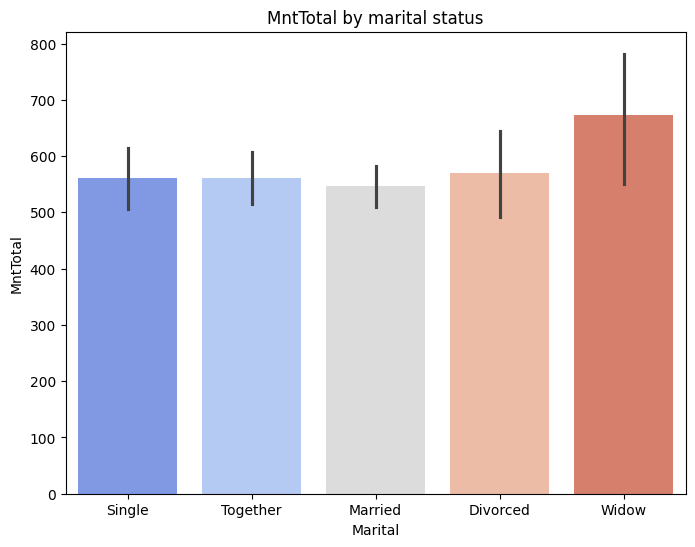

In [192]:
# Function to determine marital status
def get_marital_status(row):
    
    if row['marital_Divorced'] == 1:
        return 'Divorced'
    elif row['marital_Married'] == 1:
        return 'Married'    
    elif row['marital_Single'] == 1:
        return 'Single'   
    elif row['marital_Together'] == 1:
        return 'Together'    
    elif row['marital_Widow'] == 1:
        return 'Widow'    
    else:
        return 'Unknown'

# Create new column "Marital"
data['Marital'] = data.apply(get_marital_status, axis=1)

# Plot graph
plt.figure(figsize=(8,6))
sns.barplot(x='Marital', y='MntTotal', data=data, palette='coolwarm')
plt.title('MntTotal by marital status')
plt.xlabel='Marital status'
plt.ylabel='MntTotal'
plt.show()

In [134]:
def get_relationship(row):
    if row['marital_Married'] == 1:
        return 1
    elif row['marital_Together'] == 1:
        return 1
    else:
        return 0

data['In_relationship'] = data.apply(get_relationship, axis= 1)
data.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Marital,In_relationship
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,1,0,0,1529,1441,0,Single,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,1,0,0,21,15,0,Single,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,1,0,0,734,692,0,Together,1
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,1,0,0,48,43,0,Together,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,1,407,392,0,Married,1


In [135]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols_for_clustering = ['Income', 'MntTotal', 'In_relationship']
data_scaled = data.copy()
data_scaled[cols_for_clustering] = scaler.fit_transform(data[cols_for_clustering])
data_scaled[cols_for_clustering].describe()

,Income,MntTotal,In_relationship
count,2.202000e+03,2.202000e+03,2.202000e+03
mean,2.742785e-17,-8.873717e-17,-4.678869e-17
std,1.000227e+00,1.000227e+00,1.000227e+00
min,-2.410685e+00,-9.724232e-01,-1.348874e+00
25%,-7.926475e-01,-8.815089e-01,-1.348874e+00
50%,-1.508040e-02,-3.806058e-01,7.413589e-01
75%,8.017617e-01,7.024988e-01,7.413589e-01
max,3.006747e+00,3.048788e+00,7.413589e-01


In [193]:
from sklearn import decomposition

pca = decomposition.PCA(n_components = 2)

pca_res = pca.fit_transform(data_scaled[cols_for_clustering])

data_scaled['pc1']= pca_res[:,0]
data_scaled['pc2']= pca_res[:,1]

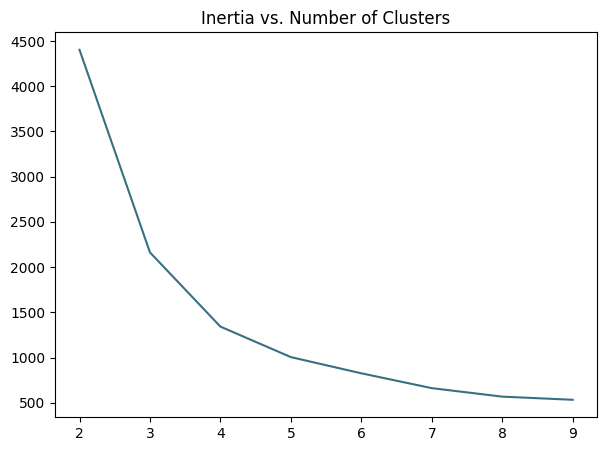

In [196]:
from sklearn.cluster import KMeans

X = data_scaled[cols_for_clustering]

inertia_list = []

for K in range(2,10):
    inertia = KMeans(n_clusters=K, random_state=7).fit(X).inertia_
    inertia_list.append(inertia)

plt.figure(figsize=(7,5))
plt.plot(range(2,10), inertia_list, color=(54 / 255, 113 / 255, 130 / 255))
plt.title("Inertia vs. Number of Clusters")
plt.xlabel="Number of Clusters (K)"
plt.ylabel='Inertia'
plt.show()

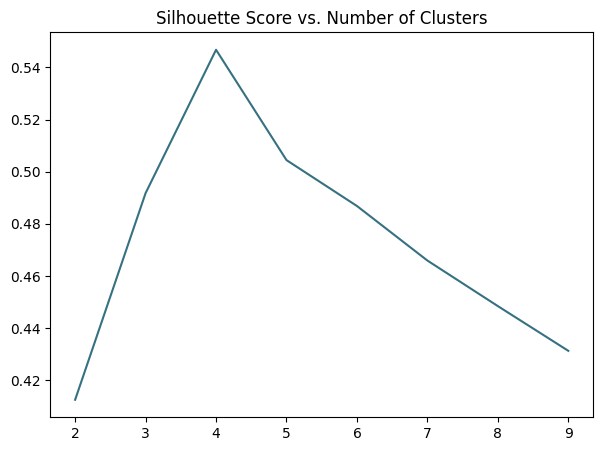

In [197]:
from sklearn.metrics import silhouette_score
silhouette_list = []
for K in range(2,10):
    model = KMeans(n_clusters=K, random_state=7)
    clusters = model.fit_predict(X)
    s_avg = silhouette_score(X, clusters)
    silhouette_list.append(s_avg)

plt.figure(figsize=(7,5))
plt.plot(range(2,10), silhouette_list, color=(54 / 255, 113 / 255, 130 / 255))
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel="Number of Clusters (K)"
plt.ylabel="Silhouette Score"
plt.show()


In [142]:
model =KMeans(n_clusters=4, random_state= 7)
model.fit(data_scaled[cols_for_clustering])
data_scaled['Cluster'] = model.predict(data_scaled[cols_for_clustering])

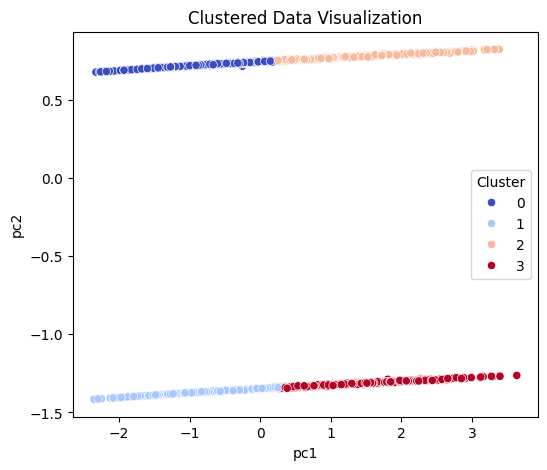

In [198]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='pc1', y='pc2', data=data_scaled, hue='Cluster', palette='coolwarm')
plt.title('Clustered Data Visualization')
plt.xlabel='Principal Component 1 (pc1)'
plt.ylabel='Principal Component 2 (pc2)'
plt.legend(title='Cluster')
plt.show()

In [144]:
data['Cluster'] = data_scaled.Cluster
data.groupby('Cluster')[cols_for_clustering].mean()

,Income,MntTotal,In_relationship
Cluster,,,
0,38027.656977,160.412791,1.0
1,37332.339956,150.761589,0.0
2,71914.598930,1153.197861,1.0
3,71946.155488,1159.612805,0.0


In [148]:
mnt_data = data.groupby('Cluster')[cols_mnt].mean().reset_index()
mnt_data.head()

,Cluster,MntTotal,MntRegularProds,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,0,160.412791,135.405814,93.372093,7.689535,39.789535,11.547674,8.013953,25.006977
1,1,150.761589,125.662252,85.450331,7.832230,38.774834,10.971302,7.732892,25.099338
2,2,1153.197861,1082.465241,625.964349,52.814617,343.479501,75.959002,54.980392,70.732620
3,3,1159.612805,1085.332317,613.862805,54.929878,357.902439,77.603659,55.314024,74.280488


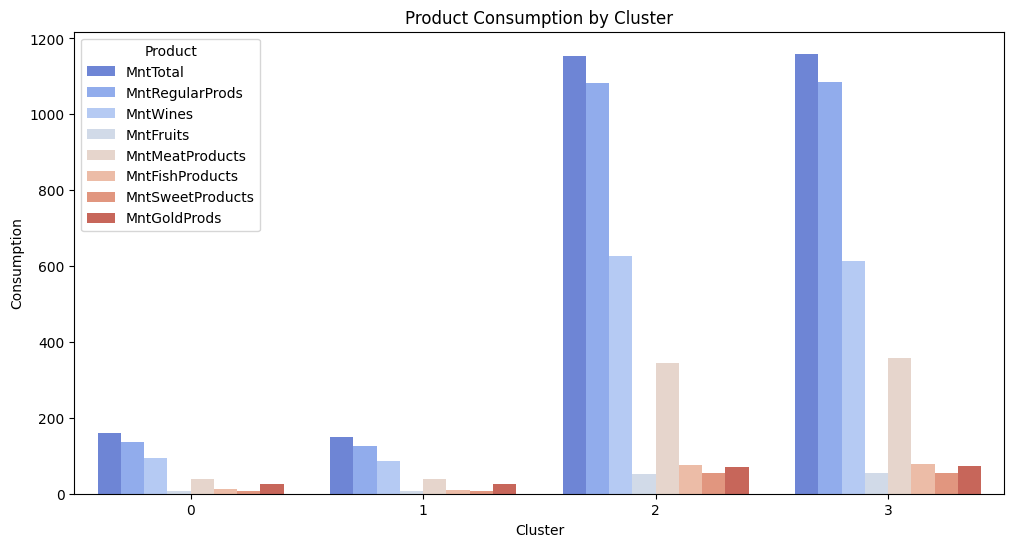

In [200]:
melted_data = pd.melt(mnt_data, id_vars="Cluster", var_name="Product", value_name="Consumption")

plt.figure(figsize=(12, 6))

sns.barplot(x="Cluster", y="Consumption", hue="Product", data=melted_data, ci=None, palette="coolwarm")

plt.title("Product Consumption by Cluster")
plt.xlabel="Cluster"
plt.ylabel="Product Consumption"
plt.xticks(rotation=0)

plt.legend(title="Product", loc="upper left")

plt.show()

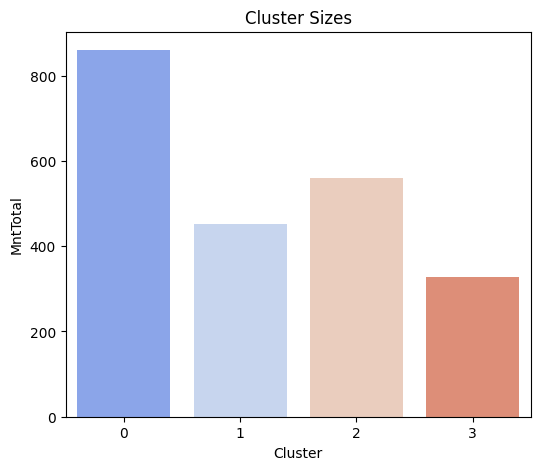

In [201]:
Cluster_sizes = data.groupby('Cluster')['MntTotal'].count().reset_index()
plt.figure(figsize=(6,5))
sns.barplot(x='Cluster', y='MntTotal', data=Cluster_sizes, palette='coolwarm')
plt.title('Cluster Sizes')
plt.xlabel='Cluster'
plt.ylabel='MntTotal'

In [152]:
total_rows = len(data)
Cluster_sizes['Share%'] = round(Cluster_sizes['MntTotal']/ total_rows*100,0)
Cluster_sizes.head()

,Cluster,MntTotal,Share%
0,0,860,39.0
1,1,453,21.0
2,2,561,25.0
3,3,328,15.0


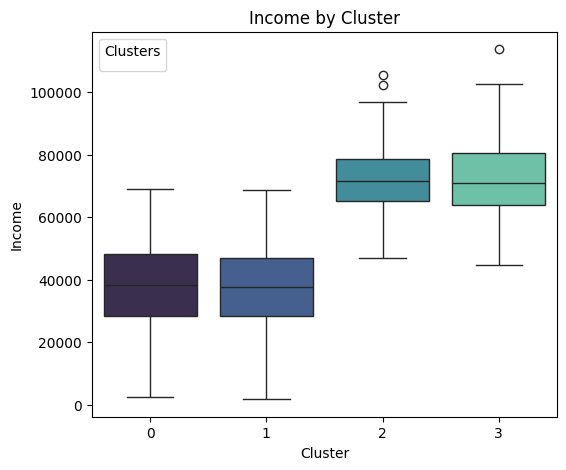

In [202]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Cluster', y='Income', data=data, palette='mako')
plt.title('Income by Cluster')
plt.xlabel='Cluster'
plt.ylabel='Income'
plt.legend(title='Clusters')
plt.show()

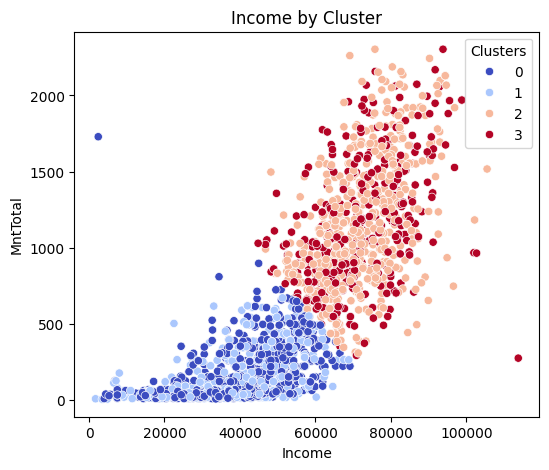

In [203]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='Income', y='MntTotal', data=data, hue='Cluster', palette='coolwarm')
plt.title('Income by Cluster')
plt.xlabel='Income'
plt.ylabel='MntTotal'
plt.legend(title='Clusters')
plt.show()

In [204]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, mean_squared_error, r2_score, accuracy_score

In [206]:
# Selecting relevant features for clustering
features = ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
            'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
            'MntGoldProds', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']

In [207]:
# Standardizing the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])

In [208]:
# Finding optimal epsilon using k-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(df_scaled)

distances, indices = neighbors_fit.kneighbors(df_scaled)

distances = np.sort(distances[:, 4], axis=0)

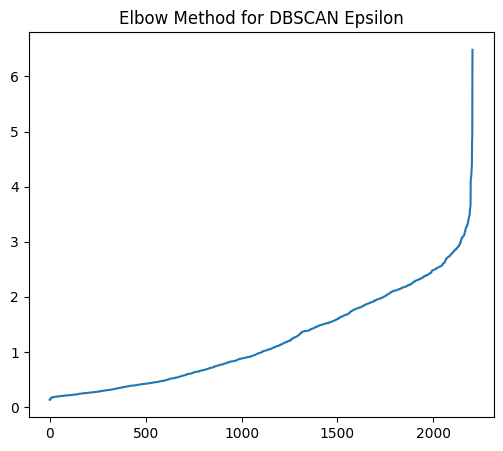

In [210]:
plt.figure(figsize=(6,5))

plt.plot(distances)

plt.xlabel='Data Points'
plt.ylabel='Epsilon (k-distance)'
plt.title('Elbow Method for DBSCAN Epsilon')

plt.show()

In [166]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['Cluster'] = dbscan.fit_predict(df_scaled)

In [167]:
# Evaluating clusters using Silhouette Score (ignoring noise points)

if len(set(df['Cluster'])) > 1:
    silhouette_avg = silhouette_score(
        df_scaled[df['Cluster'] != -1],
        df[df['Cluster'] != -1]['Cluster']
    )
    print(f'Silhouette Score: {silhouette_avg}')
else:
    print('Silhouette Score cannot be computed - only one cluster found.')

Silhouette Score: 0.1608964522054509


In [211]:
# Calculating mean squared error for model performance

def calculate_mse(df, features):
    mse_values = []

    for cluster in set(df['Cluster']):
        if cluster != -1:   # Ignore noise points
            cluster_data = df_scaled[df['Cluster'] == cluster]

            cluster_center = cluster_data.mean(axis=0)

            mse = mean_squared_error(
                cluster_data,
                np.full(cluster_data.shape, cluster_center)
            )

            mse_values.append(mse)

    return np.mean(mse_values) if mse_values else None

In [171]:
mse_score = calculate_mse(df, features)

print(f'Mean Squared Error (MSE): {mse_score}')

Mean Squared Error (MSE): 0.13560418994534085


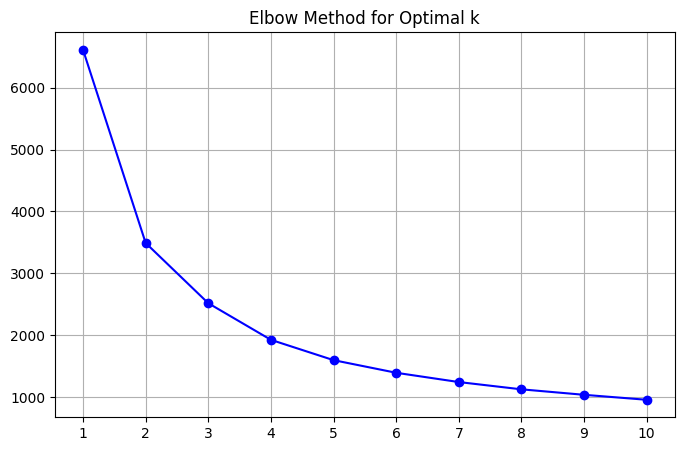

In [212]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Selecting relevant features for clustering
features = df[['MntTotal', 'Income', 'Age']]   # Adjust based on your dataset

# Standardizing the data (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Compute WCSS for different k values
wcss = []
K_range = range(1, 11)   # Testing k from 1 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)   # Inertia = WCSS

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='-', color='b')
plt.xlabel='Number of Clusters (k)'
plt.ylabel='Within-Cluster Sum of Squares (WCSS)'
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [177]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

for min_samples in range(3,10):
    dbscan = DBSCAN(eps=0.5, min_samples=min_samples)
    labels = dbscan.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'Silhouette Score For min_samples={min_samples}: {score}')

Silhouette Score For min_samples=3: 0.3817135289512547
Silhouette Score For min_samples=4: 0.3817135289512547
Silhouette Score For min_samples=5: 0.3817135289512547
Silhouette Score For min_samples=6: 0.3817135289512547
Silhouette Score For min_samples=7: 0.3817135289512547
Silhouette Score For min_samples=8: 0.3817135289512547
Silhouette Score For min_samples=9: 0.3817135289512547


In [178]:
import numpy as np 

labels = dbscan.fit_predict(X)
num_noise = np.sum(labels == -1)
total_points = len(labels)
noise_percentage = (num_noise / total_points)*100
print(f'Noise percentage: {noise_percentage:.2f}%')

Noise percentage: 0.27%


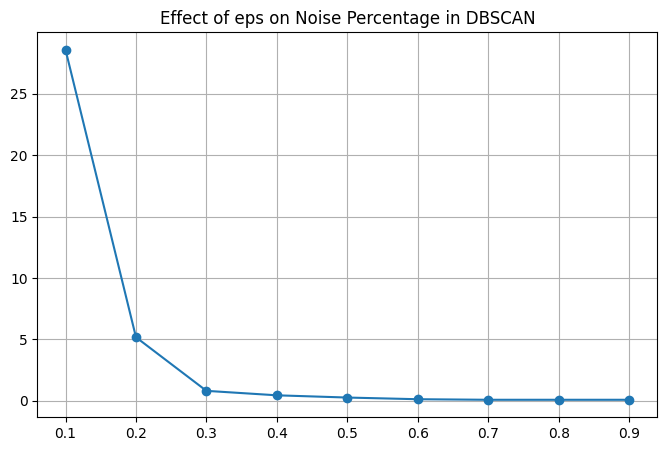

In [213]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

eps_values = np.arange(0.1, 1.0, 0.1)   # Try different eps values
noise_percentages = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=int(np.log(len(X))))   # Use log rule
    labels = dbscan.fit_predict(X)

    num_noise = np.sum(labels == -1)
    noise_percentages.append((num_noise / len(labels)) * 100)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(eps_values, noise_percentages, marker='o', linestyle='-')
plt.xlabel='Epsilon (eps)'
plt.ylabel='Noise Percentage'
plt.title('Effect of eps on Noise Percentage in DBSCAN')
plt.grid(True)
plt.show()

In [180]:
from sklearn.cluster import KMeans

KMeans = KMeans(n_clusters=3, random_state=12)
KMeans_labels = KMeans.fit_predict(X)

KMeans_score = silhouette_score(X, KMeans_labels)
print(f'K-Means silhouette Score: {KMeans_score}')

K-Means silhouette Score: 0.4917937631647986


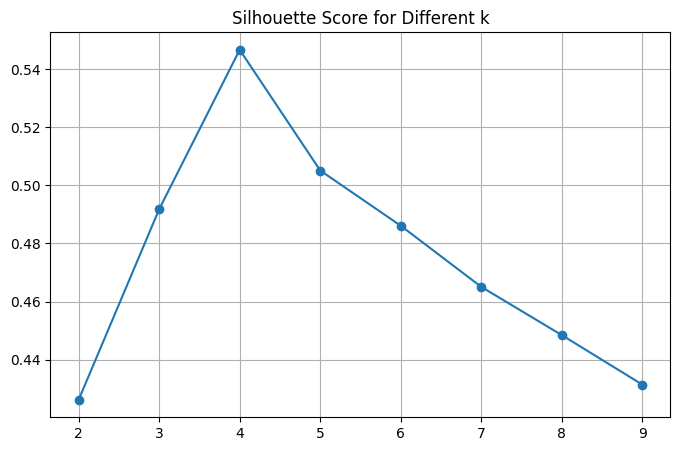

Optimal k based on silhouette score: 4


In [214]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 10)   # Testing k from 2 to 10
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='-')
plt.xlabel='Number of Clusters (k)'
plt.ylabel='Silhouette Score'
plt.title('Silhouette Score for Different k')
plt.grid(True)
plt.show()

# Print the best k
best_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal k based on silhouette score: {best_k}")

In [215]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)   # Reduce to 2D for better clustering
X_pca = pca.fit_transform(X_scaled)

best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

new_score = silhouette_score(X_pca, kmeans_labels)

print(f"New Silhouette Score after PCA: {new_score}")

New Silhouette Score after PCA: 0.6169251793629512
